In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("health_insurance.csv")
df

,age,gender,bmi,bp,children,region,smoker,medical_cost
0,23,M,31.900,157,0,southwest,smoker,16884.92400
1,20,F,36.770,160,1,southeast,non-smoker,1725.55230
2,33,F,35.000,145,3,southeast,non-smoker,4449.46200
3,37,F,23.705,153,0,northwest,non-smoker,21984.47061
4,36,F,27.880,156,0,northwest,non-smoker,3866.85520
...,...,...,...,...,...,...,...,...
1295,54,F,30.970,143,3,southwest,non-smoker,10600.54830
1296,22,M,34.920,156,0,northeast,non-smoker,2205.98080
1297,21,M,34.850,145,0,southeast,non-smoker,1629.83350
1298,22,M,24.800,150,0,northwest,non-smoker,2007.94500


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           1300 non-null   int64  
 1   gender        1300 non-null   object 
 2   bmi           1300 non-null   float64
 3   bp            1300 non-null   int64  
 4   children      1300 non-null   int64  
 5   region        1300 non-null   object 
 6   smoker        1300 non-null   object 
 7   medical_cost  1300 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 81.4+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace = True)

In [8]:
print('Shape :', df.shape)
print('Rows:', df.shape[0])
print('columns:', df.shape[1])

Shape : (1300, 8)
Rows: 1300
columns: 8


In [10]:
df.describe()

,age,bmi,bp,children,medical_cost
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,42.280769,31.581396,147.774615,1.104615,13243.214691
std,14.024847,6.356487,11.221987,1.208697,12060.371167
min,19.000000,15.290000,120.000000,0.000000,1121.873900
25%,29.750000,27.207500,140.000000,0.000000,4760.155950
50%,42.000000,31.645000,150.000000,1.000000,9388.753650
75%,54.000000,35.488750,156.000000,2.000000,16579.959053
max,69.000000,57.130000,178.000000,5.000000,63770.428010


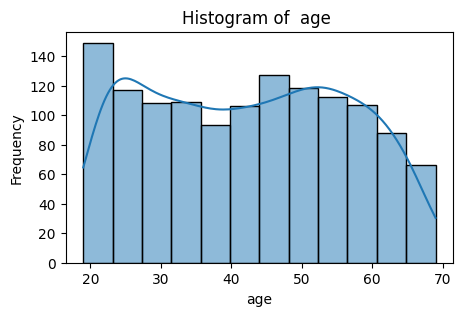

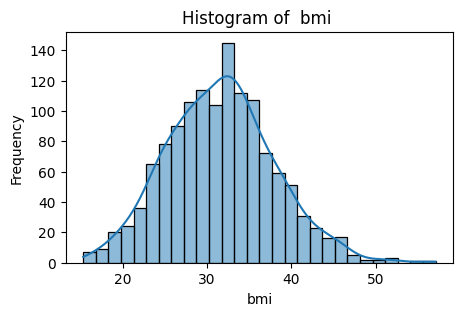

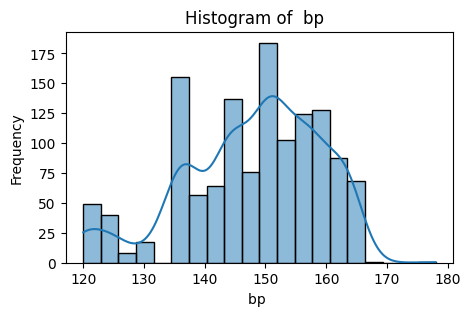

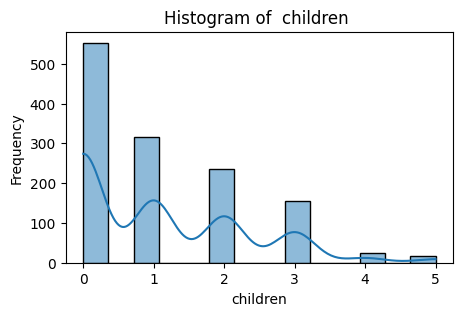

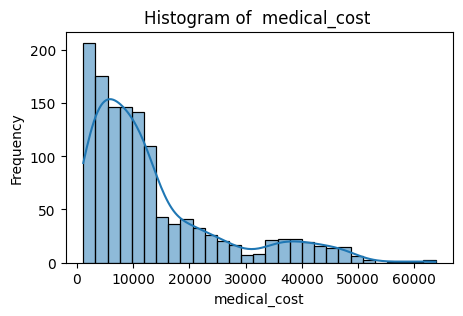

In [11]:
for col in df.select_dtypes(include = np.number):
  plt.figure(figsize = (5, 3))
  sns.histplot(df[col], kde = True)
  plt.title(f'Histogram of  {col} ')
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

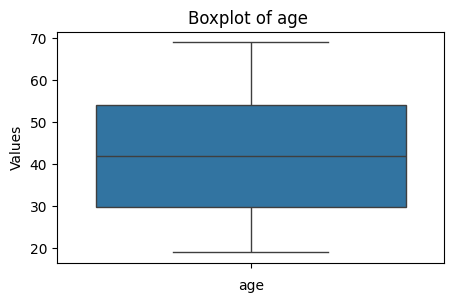

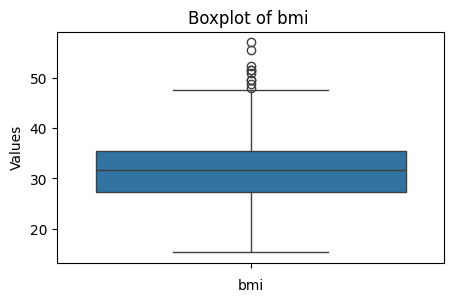

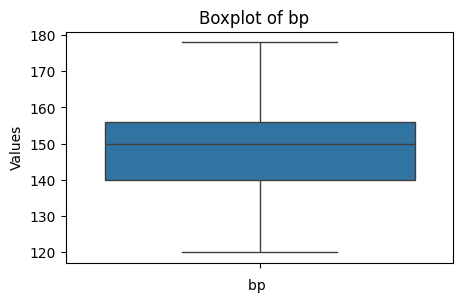

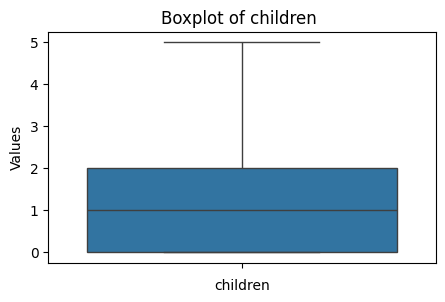

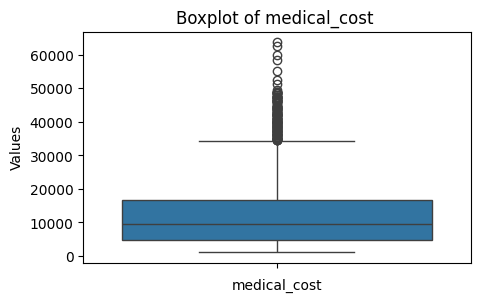

In [12]:
for col in df.select_dtypes(include = np.number):
  plt.figure(figsize = (5, 3))
  sns.boxplot(df[col])
  plt.title(f'Boxplot of {col} ')
  plt.xlabel(col)
  plt.ylabel("Values")
  plt.show()

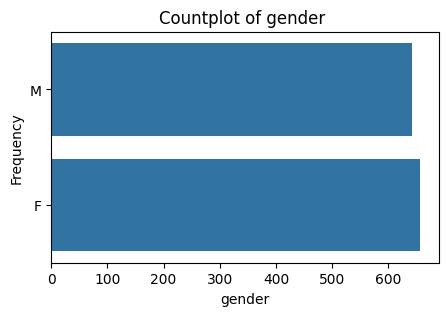

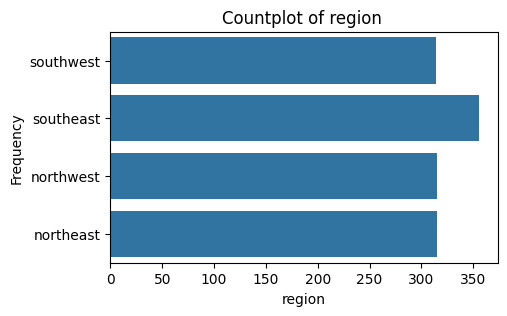

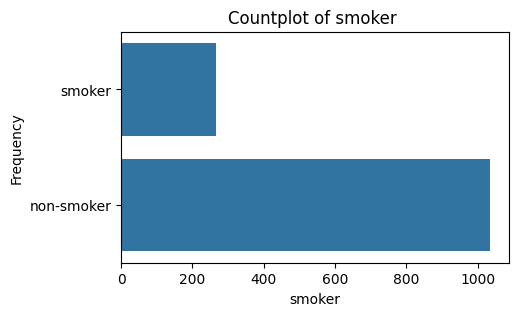

In [13]:
for col in df.select_dtypes(exclude = np.number):
  plt.figure(figsize = (5, 3))
  sns.countplot(df[col])
  plt.title(f'Countplot of {col} ')
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

In [14]:
df.loc[df['gender'] == 'F', 'gender'] = 0
df.loc[df['gender'] == 'M', 'gender'] = 1
df.loc[df['smoker'] == 'smoker', 'smoker'] = 1
df.loc[df['smoker'] == 'non-smoker', 'smoker'] = 0

In [15]:
df.head()

,age,gender,bmi,bp,children,region,smoker,medical_cost
0,23,1,31.900,157,0,southwest,1,16884.92400
1,20,0,36.770,160,1,southeast,0,1725.55230
2,33,0,35.000,145,3,southeast,0,4449.46200
3,37,0,23.705,153,0,northwest,0,21984.47061
4,36,0,27.880,156,0,northwest,0,3866.85520


In [16]:
df= pd.get_dummies(df, columns=['region'])
df.head()

,age,gender,bmi,bp,children,smoker,medical_cost,region_northeast,region_northwest,region_southeast,region_southwest
0,23,1,31.900,157,0,1,16884.92400,False,False,False,True
1,20,0,36.770,160,1,0,1725.55230,False,False,True,False
2,33,0,35.000,145,3,0,4449.46200,False,False,True,False
3,37,0,23.705,153,0,0,21984.47061,False,True,False,False
4,36,0,27.880,156,0,0,3866.85520,False,True,False,False


In [17]:
df.replace({False : 0, True:1}, inplace = True)
df.head()

,age,gender,bmi,bp,children,smoker,medical_cost,region_northeast,region_northwest,region_southeast,region_southwest
0,23,1,31.900,157,0,1,16884.92400,0,0,0,1
1,20,0,36.770,160,1,0,1725.55230,0,0,1,0
2,33,0,35.000,145,3,0,4449.46200,0,0,1,0
3,37,0,23.705,153,0,0,21984.47061,0,1,0,0
4,36,0,27.880,156,0,0,3866.85520,0,1,0,0


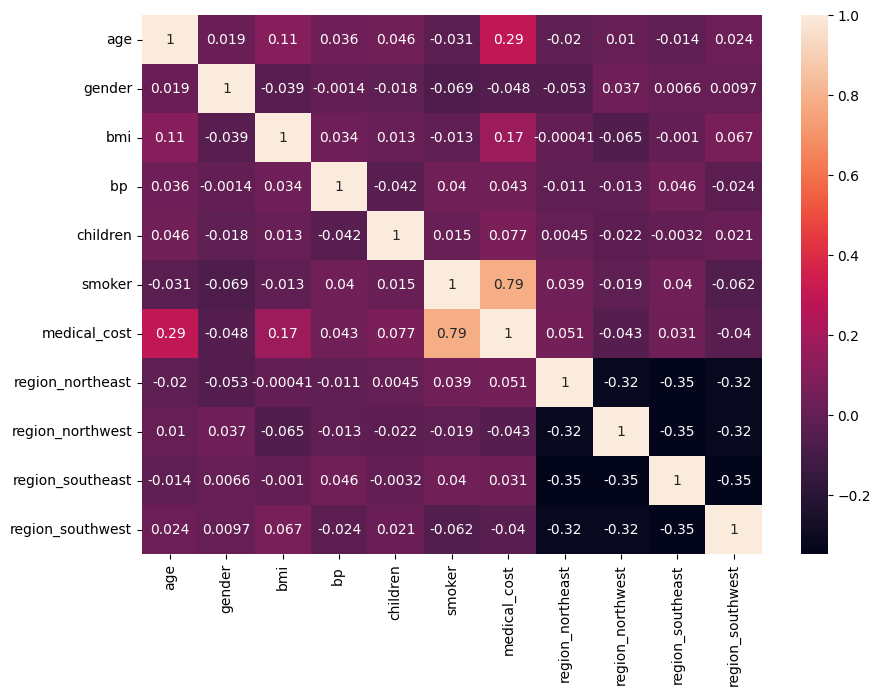

In [19]:
plt.figure(figsize = (10,7))
sns.heatmap(df.corr(),annot = True)
plt.show()

In [20]:
X = df[['smoker']]
y = df[['medical_cost']]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

In [21]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

In [23]:
from sklearn.metrics import r2_score
print("Training R2 score", np.round(r2_score(y_train, y_train_pred)))
print("Testing R2 score", np.round(r2_score(y_test, y_test_pred)))

Training R2 score 1.0
Testing R2 score 1.0


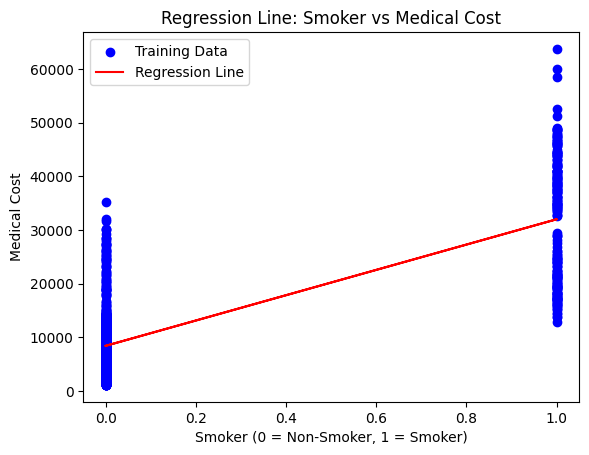

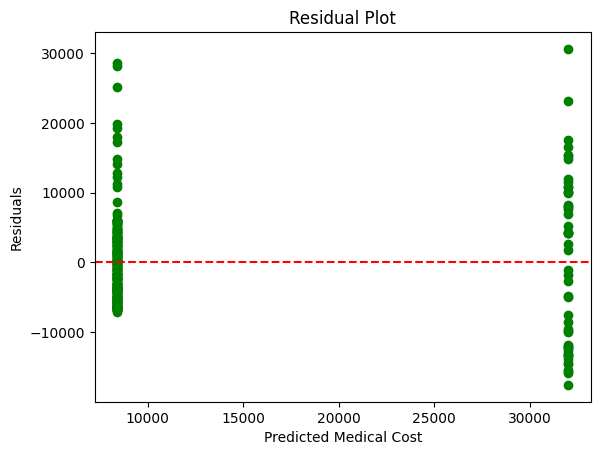

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# --- Regression Line Plot ---
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.plot(X_train, y_train_pred, color='red', label='Regression Line')
plt.xlabel('Smoker (0 = Non-Smoker, 1 = Smoker)')
plt.ylabel('Medical Cost')
plt.title('Regression Line: Smoker vs Medical Cost')
plt.legend()
plt.show()

# --- Residual Plot ---
residuals = y_test.values.flatten() - y_test_pred.flatten()

plt.scatter(y_test_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Medical Cost')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()